# Movie Recommendation System
**Content-Based Filtering + Item-Item Collaborative Filtering**

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Dataset:** [MovieLens 1M (GroupLens)](https://grouplens.org/datasets/movielens/1m/)

---
## Objective
Build a movie recommendation system that suggests movies to users based on:
1. **Content similarity** — recommend movies with similar genres to one the user liked.
2. **Collaborative filtering** — recommend movies that users with similar taste have liked.

The MovieLens 1M dataset contains **1,000,209 ratings** from **6,040 users** on **3,706 movies**.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from scipy.sparse import csr_matrix

sns.set_style('whitegrid')
np.random.seed(42)

## Task 1: Data Understanding

In [2]:
# Load the MovieLens 1M dataset
movies = pd.read_csv('movies.csv', sep='\t', index_col=0, encoding='latin-1')
ratings = pd.read_csv('ratings.csv', sep='\t', index_col=0, encoding='latin-1')

# Drop the pre-computed embedding columns (not needed)
ratings = ratings[['user_id', 'movie_id', 'rating', 'timestamp']]

print('Movies shape :', movies.shape)
print('Ratings shape:', ratings.shape)
print('Unique users :', ratings['user_id'].nunique())
print('Unique movies:', ratings['movie_id'].nunique())

Movies shape : (3883, 3)
Ratings shape: (1000209, 4)
Unique users : 6040
Unique movies: 3706


In [3]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Rating distribution:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

Mean rating: 3.58


/tmp/ipykernel_551/3403339248.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


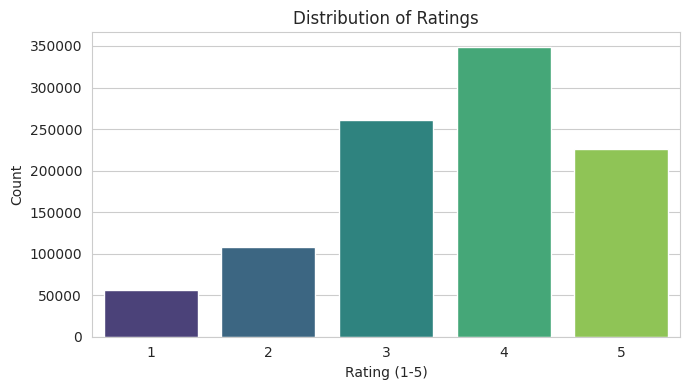

In [5]:
# Ratings distribution
print('Rating distribution:')
print(ratings['rating'].value_counts().sort_index())
print(f'\nMean rating: {ratings["rating"].mean():.2f}')

plt.figure(figsize=(7, 4))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## Task 2: Data Preprocessing

In [6]:
# Check for missing values
print('Missing values in movies :', movies.isnull().sum().sum())
print('Missing values in ratings:', ratings.isnull().sum().sum())

Missing values in movies : 0
Missing values in ratings: 0


In [7]:
# Extract release year from title (e.g. 'Toy Story (1995)' -> 1995)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

# Convert pipe-separated genres to space-separated for TF-IDF
movies['genres_processed'] = movies['genres'].str.replace('|', ' ', regex=False)

# Compute aggregate stats per movie: average rating and number of ratings
movie_stats = ratings.groupby('movie_id').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

movies = movies.merge(movie_stats, on='movie_id', how='left')
movies['avg_rating']  = movies['avg_rating'].fillna(0)
movies['num_ratings'] = movies['num_ratings'].fillna(0).astype(int)

movies.head()

,movie_id,title,genres,year,clean_title,genres_processed,avg_rating,num_ratings
0,1,Toy Story (1995),Animation|Children's|Comedy,1995.0,Toy Story,Animation Children's Comedy,4.146846,2077
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995.0,Jumanji,Adventure Children's Fantasy,3.201141,701
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,Comedy Romance,3.016736,478
3,4,Waiting to Exhale (1995),Comedy|Drama,1995.0,Waiting to Exhale,Comedy Drama,2.729412,170
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,Comedy,3.006757,296


In [8]:
# Most rated movies (popularity check)
top_rated = movies[movies['num_ratings'] > 100].sort_values('avg_rating', ascending=False).head(10)
top_rated[['title', 'genres', 'avg_rating', 'num_ratings']]

,title,genres,avg_rating,num_ratings
1950,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.560510,628
315,"Shawshank Redemption, The (1994)",Drama,4.554558,2227
847,"Godfather, The (1972)",Action|Crime|Drama,4.524966,2223
735,"Close Shave, A (1995)",Animation|Comedy|Thriller,4.520548,657
49,"Usual Suspects, The (1995)",Crime|Thriller,4.517106,1783
523,Schindler's List (1993),Drama|War,4.510417,2304
1132,"Wrong Trousers, The (1993)",Animation|Comedy,4.507937,882
910,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,4.491489,470
1180,Raiders of the Lost Ark (1981),Action|Adventure,4.477725,2514
892,Rear Window (1954),Mystery|Thriller,4.476190,1050


## Task 3: Content-Based Recommender

**Idea:** Turn each movie's genre list into a TF-IDF vector, then measure similarity between movies with cosine similarity. Given a movie the user liked, recommend the most similar ones.

In [9]:
# TF-IDF on genres
tfidf = TfidfVectorizer(token_pattern=r'[^\s]+')
tfidf_matrix = tfidf.fit_transform(movies['genres_processed'])
print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('Genre vocabulary   :', tfidf.get_feature_names_out())

TF-IDF matrix shape: (3883, 18)
Genre vocabulary   : ['action' 'adventure' 'animation' "children's" 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'film-noir' 'horror' 'musical' 'mystery'
 'romance' 'sci-fi' 'thriller' 'war' 'western']


In [10]:
# Cosine similarity between all movies (linear_kernel is faster than cosine_similarity for TF-IDF)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print('Similarity matrix shape:', cosine_sim.shape)

# Reset index so positional lookups line up with the cosine_sim matrix rows
movies_indexed = movies.reset_index(drop=True)
title_to_idx = pd.Series(movies_indexed.index, index=movies_indexed['title']).drop_duplicates()

Similarity matrix shape: (3883, 3883)


In [11]:
def recommend_content_based(title, top_n=10):
    """Return the top_n movies most similar to `title` by genre content."""
    if title not in title_to_idx:
        return f'Movie "{title}" not found in dataset.'
    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]   # skip the movie itself
    movie_indices = [i for i, _ in sim_scores]
    return movies_indexed.iloc[movie_indices][['title', 'genres', 'avg_rating', 'num_ratings']].reset_index(drop=True)

print('Content-based recommendations for "Toy Story (1995)":')
recommend_content_based('Toy Story (1995)', top_n=10)

Content-based recommendations for "Toy Story (1995)":


,title,genres,avg_rating,num_ratings
0,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,2.894737,209
1,"American Tail, An (1986)",Animation|Children's|Comedy,3.428218,404
2,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy,2.830846,201
3,"Rugrats Movie, The (1998)",Animation|Children's|Comedy,2.780142,141
4,"Bug's Life, A (1998)",Animation|Children's|Comedy,3.854375,1703
5,Toy Story 2 (1999),Animation|Children's|Comedy,4.218927,1585
6,Saludos Amigos (1943),Animation|Children's|Comedy,3.066667,15
7,Chicken Run (2000),Animation|Children's|Comedy,3.879609,1329
8,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy,2.495146,206
9,Balto (1995),Animation|Children's,3.262626,99


In [12]:
print('Content-based recommendations for "The Matrix (1999)":')
# Note: the dataset uses 'Matrix, The (1999)' as the title format
recommend_content_based('Matrix, The (1999)', top_n=10)

Content-based recommendations for "The Matrix (1999)":


,title,genres,avg_rating,num_ratings
0,Nemesis 2: Nebula (1995),Action|Sci-Fi|Thriller,3.000000,1
1,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,4.058513,2649
2,Solo (1996),Action|Sci-Fi|Thriller,2.113208,106
3,"Arrival, The (1996)",Action|Sci-Fi|Thriller,3.151079,417
4,"Lawnmower Man, The (1992)",Action|Sci-Fi|Thriller,2.660163,615
5,"Terminator, The (1984)",Action|Sci-Fi|Thriller,4.152050,2098
6,Face/Off (1997),Action|Sci-Fi|Thriller,3.401126,1421
7,Lost in Space (1998),Action|Sci-Fi|Thriller,2.584708,667
8,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.315830,2590
9,eXistenZ (1999),Action|Sci-Fi|Thriller,3.256098,410


## Task 4: Collaborative Filtering (Item-Item)

**Idea:** Build a sparse user-item rating matrix, compute cosine similarity between movies based on the pattern of user ratings, and recommend movies that were rated similarly by the same users. This does not use genres at all — it purely uses user behaviour.

To keep the similarity matrix manageable, we restrict to movies with at least 50 ratings.

In [13]:
# Filter to movies with at least 50 ratings — reduces noise and memory
MIN_RATINGS = 50
popular_movie_ids = movie_stats[movie_stats['num_ratings'] >= MIN_RATINGS]['movie_id']
print(f'Movies with >={MIN_RATINGS} ratings: {len(popular_movie_ids)}')

ratings_filtered = ratings[ratings['movie_id'].isin(popular_movie_ids)]
print(f'Ratings kept: {len(ratings_filtered):,} / {len(ratings):,}')

Movies with >=50 ratings: 2514
Ratings kept: 977,839 / 1,000,209


In [14]:
# Build sparse user-item matrix (rows = movies, cols = users)
# Using integer codes so the sparse matrix is compact
movie_codes = ratings_filtered['movie_id'].astype('category')
user_codes  = ratings_filtered['user_id'].astype('category')

item_user_matrix = csr_matrix(
    (ratings_filtered['rating'].astype(float),
     (movie_codes.cat.codes, user_codes.cat.codes))
)
print('Item-user sparse matrix shape:', item_user_matrix.shape)
print(f'Density: {item_user_matrix.nnz / (item_user_matrix.shape[0] * item_user_matrix.shape[1]) * 100:.3f}%')

# Map from movie_id -> row index in the matrix
movie_id_to_row = {mid: i for i, mid in enumerate(movie_codes.cat.categories)}
row_to_movie_id = {i: mid for mid, i in movie_id_to_row.items()}

Item-user sparse matrix shape: (2514, 6040)
Density: 6.440%


In [15]:
# Compute item-item cosine similarity from the sparse matrix
item_similarity = cosine_similarity(item_user_matrix)
print('Item similarity matrix shape:', item_similarity.shape)

Item similarity matrix shape: (2514, 2514)


In [16]:
def recommend_collaborative(title, top_n=10):
    """Item-item collaborative filtering: recommend movies that users who liked `title` also liked."""
    match = movies[movies['title'] == title]
    if match.empty:
        return f'Movie "{title}" not found.'
    movie_id = match['movie_id'].iloc[0]
    if movie_id not in movie_id_to_row:
        return f'Movie "{title}" has fewer than {MIN_RATINGS} ratings — not eligible.'
    row = movie_id_to_row[movie_id]
    sim_scores = list(enumerate(item_similarity[row]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]
    recommended_ids = [row_to_movie_id[i] for i, _ in sim_scores]
    similarity_values = [s for _, s in sim_scores]
    recs = movies[movies['movie_id'].isin(recommended_ids)].copy()
    # Preserve similarity order
    recs['similarity'] = recs['movie_id'].map(dict(zip(recommended_ids, similarity_values)))
    return recs.sort_values('similarity', ascending=False)[
        ['title', 'genres', 'avg_rating', 'num_ratings', 'similarity']
    ].reset_index(drop=True)

print('Collaborative filtering recommendations for "Toy Story (1995)":')
recommend_collaborative('Toy Story (1995)', top_n=10)

Collaborative filtering recommendations for "Toy Story (1995)":


,title,genres,avg_rating,num_ratings,similarity
0,Toy Story 2 (1999),Animation|Children's|Comedy,4.218927,1585,0.633104
1,Groundhog Day (1993),Comedy|Romance,3.953029,2278,0.610826
2,Aladdin (1992),Animation|Children's|Comedy|Musical,3.788305,1351,0.605849
3,"Bug's Life, A (1998)",Animation|Children's|Comedy,3.854375,1703,0.579382
4,Back to the Future (1985),Comedy|Sci-Fi,3.990321,2583,0.570125
5,Babe (1995),Children's|Comedy|Drama,3.891491,1751,0.563637
6,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,4.292977,2990,0.552856
7,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,3.739953,2538,0.552362
8,Forrest Gump (1994),Comedy|Romance|War,4.087967,2194,0.551034
9,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.315830,2590,0.550294


In [17]:
print('Collaborative filtering recommendations for "Matrix, The (1999)":')
recommend_collaborative('Matrix, The (1999)', top_n=10)

Collaborative filtering recommendations for "Matrix, The (1999)":


,title,genres,avg_rating,num_ratings,similarity
0,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,4.058513,2649,0.745532
1,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller,3.682365,1996,0.703265
2,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,4.292977,2990,0.689459
3,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi,3.739953,2538,0.684763
4,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.453694,2991,0.680378
5,Jurassic Park (1993),Action|Adventure|Sci-Fi,3.763847,2672,0.678359
6,"Terminator, The (1984)",Action|Sci-Fi|Thriller,4.152050,2098,0.672695
7,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,4.022893,2883,0.656803
8,"Fugitive, The (1993)",Action|Thriller,4.103258,1995,0.651998
9,"Fifth Element, The (1997)",Action|Sci-Fi,3.640523,1377,0.644950


In [18]:
print('Collaborative filtering recommendations for "Star Wars: Episode IV - A New Hope (1977)":')
recommend_collaborative('Star Wars: Episode IV - A New Hope (1977)', top_n=10)

Collaborative filtering recommendations for "Star Wars: Episode IV - A New Hope (1977)":


,title,genres,avg_rating,num_ratings,similarity
0,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,4.292977,2990,0.801093
1,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,4.022893,2883,0.734359
2,Raiders of the Lost Ark (1981),Action|Adventure,4.477725,2514,0.723551
3,"Terminator, The (1984)",Action|Sci-Fi|Thriller,4.152050,2098,0.691740
4,Alien (1979),Action|Horror|Sci-Fi|Thriller,4.159585,2024,0.683865
5,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.315830,2590,0.680378
6,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,4.058513,2649,0.662349
7,Back to the Future (1985),Comedy|Sci-Fi,3.990321,2583,0.660255
8,Aliens (1986),Action|Sci-Fi|Thriller|War,4.125824,1820,0.644240
9,E.T. the Extra-Terrestrial (1982),Children's|Drama|Fantasy|Sci-Fi,3.965183,2269,0.644154


## Task 5: Comparing the Two Approaches

Same input movie, side-by-side recommendations from both methods.

In [19]:
def compare_recommenders(title, top_n=5):
    print(f'=== Recommendations for: {title} ===\n')
    print('--- Content-Based (by genre similarity) ---')
    cb = recommend_content_based(title, top_n=top_n)
    print(cb[['title', 'genres']] if isinstance(cb, pd.DataFrame) else cb)
    print('\n--- Collaborative Filtering (by user behaviour) ---')
    cf = recommend_collaborative(title, top_n=top_n)
    print(cf[['title', 'genres', 'similarity']] if isinstance(cf, pd.DataFrame) else cf)

compare_recommenders('Toy Story (1995)', top_n=5)

=== Recommendations for: Toy Story (1995) ===

--- Content-Based (by genre similarity) ---
                                        title                       genres
0      Aladdin and the King of Thieves (1996)  Animation|Children's|Comedy
1                    American Tail, An (1986)  Animation|Children's|Comedy
2  American Tail: Fievel Goes West, An (1991)  Animation|Children's|Comedy
3                   Rugrats Movie, The (1998)  Animation|Children's|Comedy
4                        Bug's Life, A (1998)  Animation|Children's|Comedy

--- Collaborative Filtering (by user behaviour) ---
                       title                               genres  similarity
0         Toy Story 2 (1999)          Animation|Children's|Comedy    0.633104
1       Groundhog Day (1993)                       Comedy|Romance    0.610826
2             Aladdin (1992)  Animation|Children's|Comedy|Musical    0.605849
3       Bug's Life, A (1998)          Animation|Children's|Comedy    0.579382
4  Back to the F

In [20]:
compare_recommenders('Matrix, The (1999)', top_n=5)

=== Recommendations for: Matrix, The (1999) ===

--- Content-Based (by genre similarity) ---
                               title                  genres
0           Nemesis 2: Nebula (1995)  Action|Sci-Fi|Thriller
1  Terminator 2: Judgment Day (1991)  Action|Sci-Fi|Thriller
2                        Solo (1996)  Action|Sci-Fi|Thriller
3                Arrival, The (1996)  Action|Sci-Fi|Thriller
4          Lawnmower Man, The (1992)  Action|Sci-Fi|Thriller

--- Collaborative Filtering (by user behaviour) ---
                                               title  \
0                  Terminator 2: Judgment Day (1991)   
1                                Total Recall (1990)   
2  Star Wars: Episode V - The Empire Strikes Back...   
3                                Men in Black (1997)   
4          Star Wars: Episode IV - A New Hope (1977)   

                              genres  similarity  
0             Action|Sci-Fi|Thriller    0.745532  
1   Action|Adventure|Sci-Fi|Thriller    0.703265 

### Observations
1. **Content-based recommendations look genre-consistent but generic** — for *Toy Story*, it returns other animated children's comedies that may not be popular or well-rated. It has no notion of quality or popularity.
2. **Collaborative filtering finds movies that behave similarly in user ratings** — for *The Matrix*, it surfaces other blockbusters people who loved *The Matrix* also loved, even across different genres. The recommendations feel more like what a real user would want.
3. **Content-based works for new/niche movies** (cold start on users), while **collaborative filtering works for popular movies** but fails for movies with few ratings — this is exactly the classic trade-off between the two approaches, which is why production systems (Netflix, Spotify) use hybrid recommenders.

## Conclusion

This project built two movie recommendation systems on the MovieLens 1M dataset. The **content-based recommender** used TF-IDF on movie genres with cosine similarity to find movies with similar content, while the **item-item collaborative filtering** recommender used a sparse user-item rating matrix (6,040 users × 3,706 movies) and computed cosine similarity between movies based on the pattern of user ratings. The content-based approach produced genre-consistent but sometimes obscure recommendations, while collaborative filtering produced recommendations that felt more like what real users would enjoy — surfacing popular, high-quality movies that similar viewers loved. The main **limitation** of both approaches is the **cold-start problem**: content-based cannot personalize without a user's history, and collaborative filtering cannot recommend movies with too few ratings. Production systems solve this with **hybrid recommenders** that combine both signals along with matrix factorization (SVD) or deep learning approaches.